In [114]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt 

In [115]:
data = pd.read_csv(r"C:\Users\Prakash\Desktop\Ai_learning_journey\Month2-machine-learning\house-price-prediction\housing.csv")

In [116]:
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [117]:
data["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [118]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

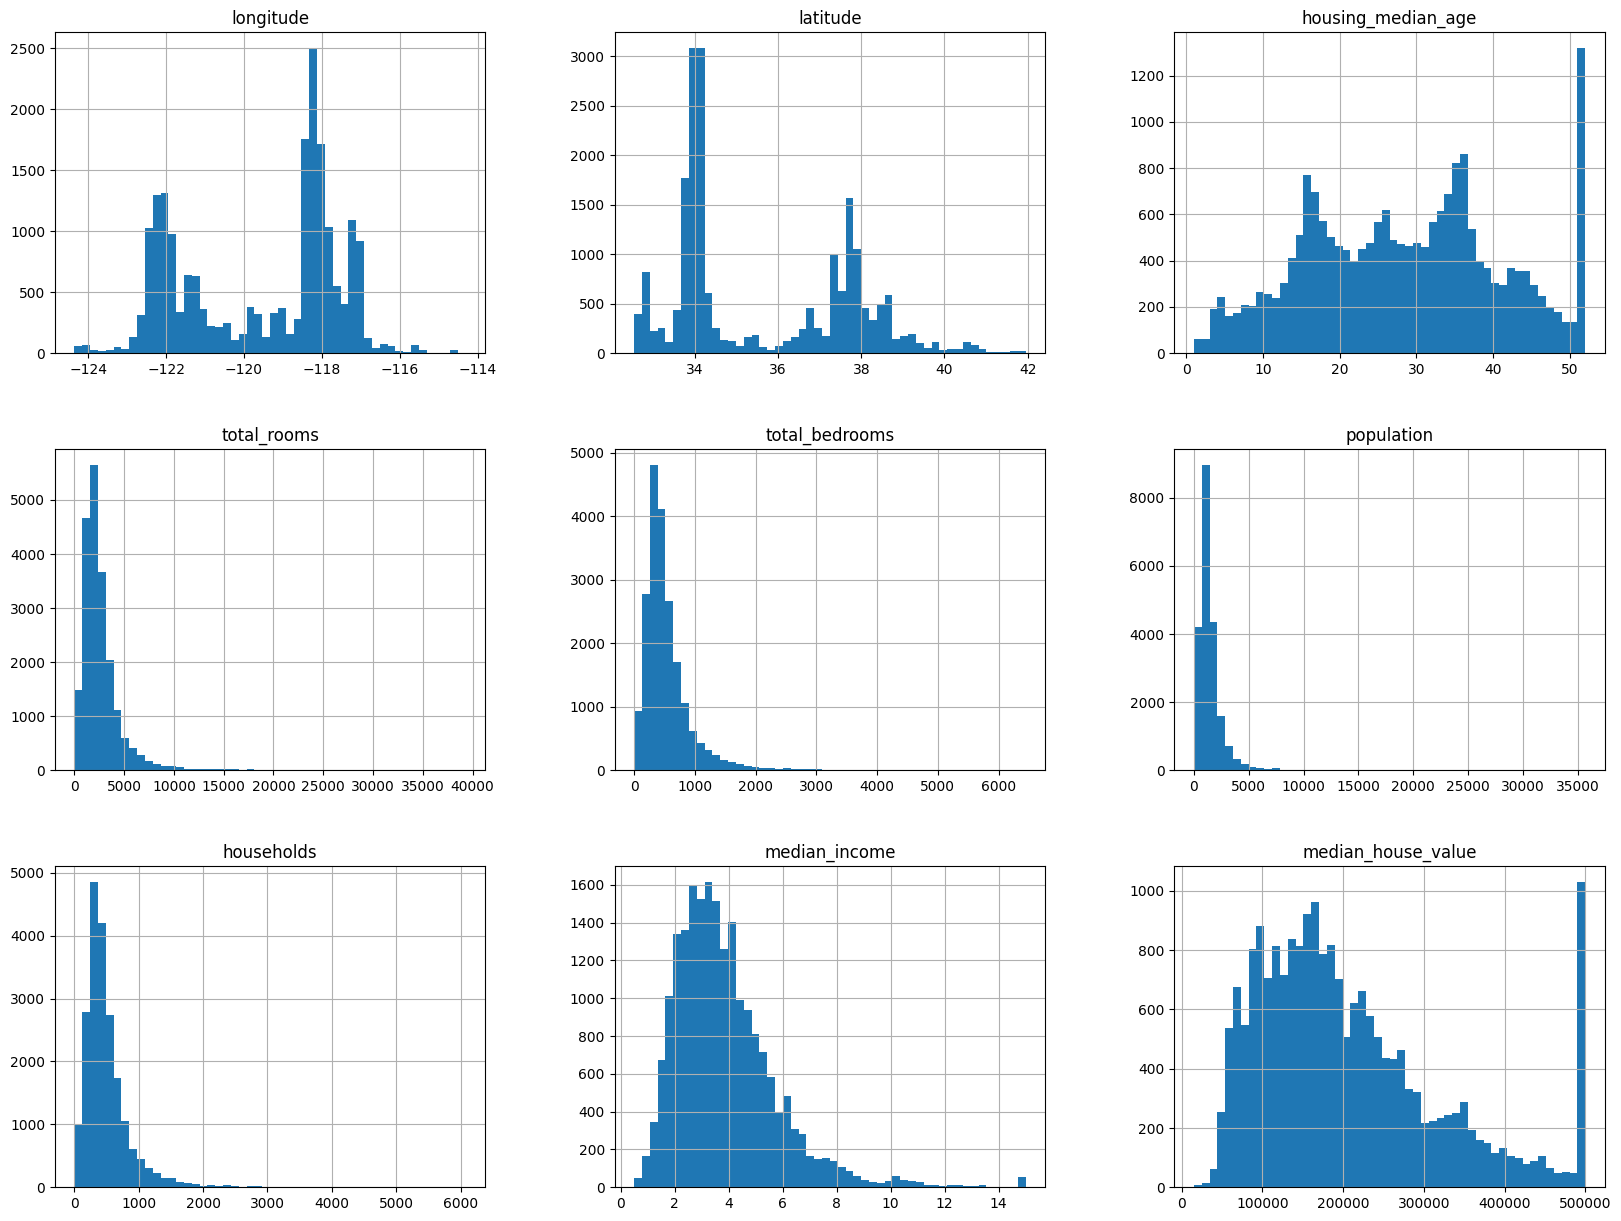

In [119]:
data.hist(bins=50,figsize=(20,15))

<Axes: xlabel='longitude', ylabel='latitude'>

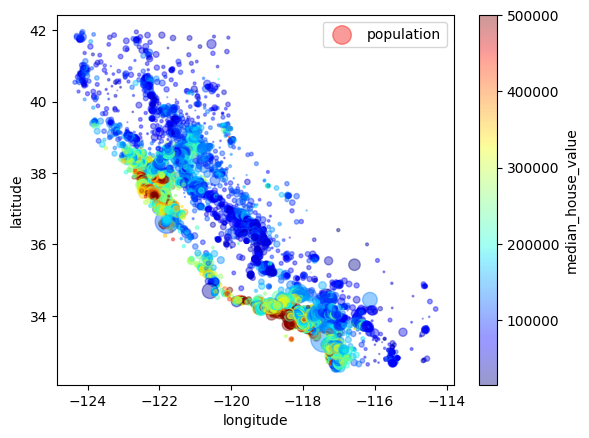

In [120]:
data.plot(kind ="scatter", x ="longitude",y="latitude", alpha = 0.4,s = data["population"]/100,label = "population", c = "median_house_value", cmap = "jet" ,colorbar = True)

In [121]:
corr_matrix = data.corr(numeric_only=True)
corr_matrix['median_house_value'].sort_values(ascending = False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

In [122]:
data_na = data.dropna(subset=["total_bedrooms"])
data_na.shape

(20433, 10)

In [123]:
dummies = pd.get_dummies(data_na.ocean_proximity)
data_na_dummies = pd.concat([data_na,dummies],axis='columns')
data_na_dummies.head()

data_clear = data_na_dummies.drop(['ocean_proximity','ISLAND'],axis='columns')
data_clear.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


In [124]:
#creating feature and lebeling datasets
X = data_clear.drop(columns=["median_house_value"])
X.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,False,False,True,False


In [125]:
y = data_clear["median_house_value"]
y.head()

0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: median_house_value, dtype: float64

In [126]:
#importing test train model 
from sklearn.model_selection import train_test_split

#splitting the data to test and train

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)



In [127]:
#importing lenear regression model

from sklearn.linear_model import LinearRegression

OLS = LinearRegression()
OLS.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [128]:
#display the intercept and coffiecient of the OLS model

print("OLS intercept:" ,str(OLS.intercept_))
print("OLS coffiecient:",str(OLS.coef_))
print("the R -Squrared model is:" , OLS.score(X_train,y_train))

OLS intercept: -2085620.3876403193
OLS coffiecient: [-2.71087463e+04 -2.56578075e+04  1.08136421e+03 -6.32214552e+00
  1.03004042e+02 -3.64097514e+01  4.31427249e+01  3.92770830e+04
 -2.13653374e+05 -2.52893592e+05 -2.19885791e+05 -2.10486897e+05]
the R -Squrared model is: 0.6456482397646103


In [129]:
#predicting with OLS 
y_pred = OLS.predict(X_test)
performance = pd.DataFrame({'Prediction': y_pred,'Actual_Values':y_test})
performance['Error'] = performance['Actual_Values'] - performance['Prediction']
performance.head()


,Prediction,Actual_Values,Error
14416,201882.959868,245800.0,43917.040132
16383,147279.682144,137900.0,-9379.682144
7731,207796.609798,218200.0,10403.390202
1410,180487.576722,220800.0,40312.423278
1335,190323.923130,170500.0,-19823.923130


In [141]:
#preparing the data for plotiing 
performance.reset_index(drop=True,inplace=True)
performance.reset_index(inplace=True)

performance.head()


#
#fix here indexing to get the correct data and plot the graph


,index,Prediction,Actual_Values,Error
0,0,201882.959868,245800.0,43917.040132
1,1,147279.682144,137900.0,-9379.682144
2,2,207796.609798,218200.0,10403.390202
3,3,180487.576722,220800.0,40312.423278
4,4,190323.923130,170500.0,-19823.923130


In [131]:
# # import boolean columns to int

bool_cols = X_train.select_dtypes(include='bool').columns
X_train[bool_cols] = X_train[bool_cols].astype(int)

In [132]:
# #remove if remaining const in there

if 'const' in X_train.columns:
    X_train = X_train.drop(columns=['const'])


In [133]:
# #remove if remaining const in there

if 'const' in X_train.columns:
    X_train = X_train.drop(columns=['const'])


In [134]:
# # add everything to float 

X_train = X_train.astype(float)

In [135]:
# #add constant
import statsmodels.api as sm

X_train = sm.add_constant(X_train)

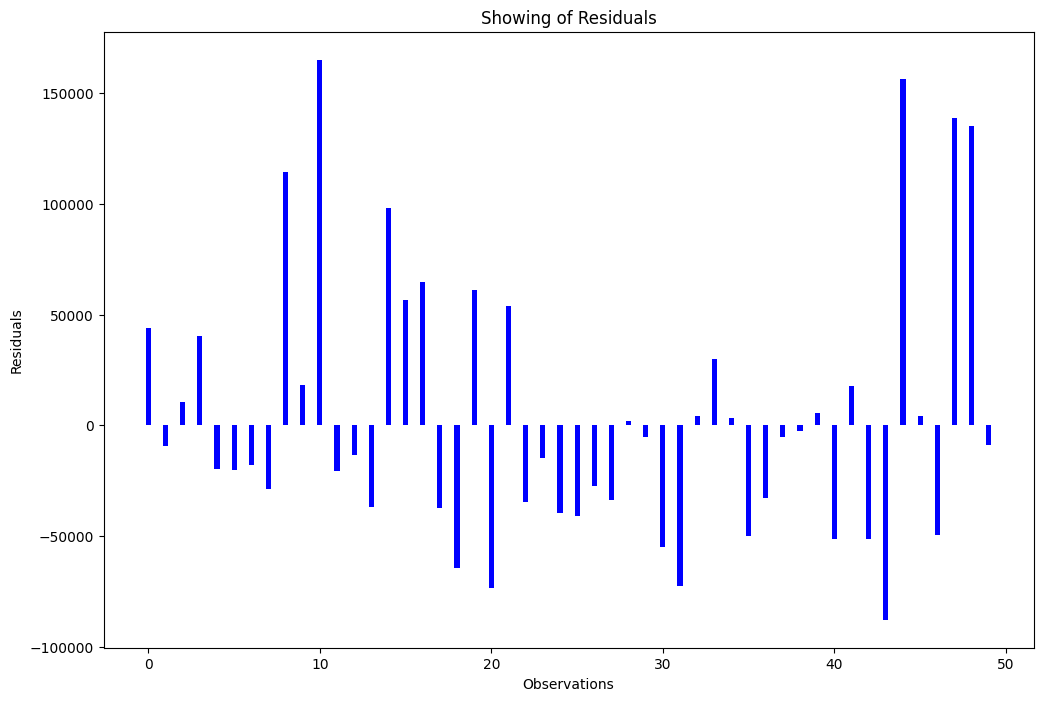

In [143]:
#plot the residuals
fig = plt.figure(figsize=(12,8))
plt.bar('index','Error',data=performance[:50],color ='blue',width= 0.3)
plt.xlabel("Observations")
plt.ylabel("Residuals")
plt.title("Showing of Residuals")
plt.show()

In [137]:
#fitting Ols

nicer_ols = sm.OLS(y_train,X_train).fit()
nicer_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     median_house_value   R-squared:                       0.646
Model:                            OLS   Adj. R-squared:                  0.645
Method:                 Least Squares   F-statistic:                     2480.
Date:                Tue, 06 Jan 2026   Prob (F-statistic):               0.00
Time:                        13:43:40   Log-Likelihood:            -2.0520e+05
No. Observations:               16346   AIC:                         4.104e+05
Df Residuals:                   16333   BIC:                         4.105e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const              -2.086e+06   1.06e+05    -19.600      0.000   -2.29e+06   -1.88e+06
longitude          -2.711e+04   1135.213    -23.880      0.000   -2.93e+04   -2.49e+04
latitude           -2.566e+04   1119.515    -22.919      0.000   -2.79e+04   -2.35e+04
housing_median_age  1081.3642     49.005     22.066      0.000     985.308    1177.420
total_rooms           -6.3221      0.888     -7.118      0.000      -8.063      -4.581
total_bedrooms       103.0040      7.563     13.620      0.000      88.180     117.828
population           -36.4098      1.178    -30.917      0.000     -38.718     -34.101
households            43.1427      8.169      5.282      0.000      27.131      59.154
median_income       3.928e+04    377.248    104.115      0.000    3.85e+04       4e+04
<1H OCEAN          -2.137e+05   3.96e+04     -5.396      0.000   -2.91e+05   -1.36e+05
INLAND             -2.529e+05   3.97e+04     -6.377      0.000   -3.31e+05   -1.75e+05
NEAR BAY           -2.199e+05   3.96e+04     -5.549      0.000   -2.98e+05   -1.42e+05
NEAR OCEAN         -2.105e+05   3.96e+04     -5.315      0.000   -2.88e+05   -1.33e+05
==============================================================================
Omnibus:                     4096.788   Durbin-Watson:                   1.981
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            15968.414
Skew:                           1.204   Prob(JB):                         0.00
Kurtosis:                       7.201   Cond. No.                     8.33e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.33e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
#standard scalar

from sklearn.preprocessing import StandardScaler


In [ ]:
#bias and variance



In [ ]:
#knn
